# Influence du ratio d'anomalies LLM

Ce notebook compare **SERAD-KG** (`alpha = 0.5`) et **LoGNet** sur les protocoles chronological et pooled. Les ratios d'anomalies du train sont 1 %, 2,5 %, 5 %, 10 % et 20 %. La validation et le test restent fixés à 10 %.

Chaque résultat est calculé sur les seeds 41 à 45 et présenté sous la forme **moyenne ± écart-type**. Le ratio de 10 % est chargé depuis les expériences CPU précédentes ; les autres ratios proviennent du balayage dédié.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import Markdown, display
except ImportError:  # Permet aussi l'exécution comme script Python.
    Markdown = str
    display = print
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

REPO_DIR = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "outputs").is_dir() and (path / "src").is_dir()
)
OUTPUTS_DIR = REPO_DIR / "outputs"
RATIOS = (0.01, 0.025, 0.05, 0.1, 0.2)
SEEDS = (41, 42, 43, 44, 45)
PROTOCOLS = ("chronological_llm", "pooled_30_llm")
MODELS = ("lognet", "serad_kg")

REPO_DIR

PosixPath('/Users/lmoncla/git/github.com/lmoncla/knowledge-graph-anomaly-detection')

## Chargement et vérification des résultats

In [2]:
def result_path(model: str, protocol: str, ratio: float) -> Path:
    ratio_name = f"{ratio:g}"
    if ratio == 0.1:
        if model == "lognet":
            return OUTPUTS_DIR / "cpu_llm_lognet" / protocol / "ratio_0.1" / "summary_by_seed.csv"
        return (
            OUTPUTS_DIR / "cpu_llm_alpha_sweep" / protocol / "ratio_0.1"
            / "alpha_0.5" / "summary_by_seed.csv"
        )

    base = OUTPUTS_DIR / "cpu_llm_ratio_sweep" / model
    if model == "serad_kg":
        base = base / "alpha_0.5"
    return base / protocol / f"ratio_{ratio_name}" / "summary_by_seed.csv"


frames = []
for model in MODELS:
    for protocol in PROTOCOLS:
        for ratio in RATIOS:
            path = result_path(model, protocol, ratio)
            if not path.is_file():
                raise FileNotFoundError(path)
            frame = pd.read_csv(path)
            frame["model"] = model
            frame["protocol"] = protocol
            frame["ratio"] = ratio
            frames.append(frame)

results = pd.concat(frames, ignore_index=True)

completeness = (
    results.groupby(["protocol", "model", "ratio"], as_index=False)
    .agg(n_seeds=("seed", "nunique"), n_ok=("status", lambda values: values.eq("ok").sum()))
)
assert len(results) == len(PROTOCOLS) * len(MODELS) * len(RATIOS) * len(SEEDS)
assert completeness["n_seeds"].eq(len(SEEDS)).all()
assert completeness["n_ok"].eq(len(SEEDS)).all()
display(Markdown(f"**{len(results)} runs chargés ; toutes les configurations contiennent cinq seeds valides.**"))
display(completeness)

**100 runs chargés ; toutes les configurations contiennent cinq seeds valides.**

,protocol,model,ratio,n_seeds,n_ok
0,chronological_llm,lognet,0.010,5,5
1,chronological_llm,lognet,0.025,5,5
2,chronological_llm,lognet,0.050,5,5
3,chronological_llm,lognet,0.100,5,5
4,chronological_llm,lognet,0.200,5,5
5,chronological_llm,serad_kg,0.010,5,5
6,chronological_llm,serad_kg,0.025,5,5
7,chronological_llm,serad_kg,0.050,5,5
8,chronological_llm,serad_kg,0.100,5,5
9,chronological_llm,serad_kg,0.200,5,5


In [3]:
METRICS = {
    "auc_test": "AUROC",
    "auprc_test": "AUPRC",
    "precision_test": "Précision",
    "recall_test": "Rappel",
    "f1_test": "F1",
}
MODEL_LABELS = {"lognet": "LoGNet", "serad_kg": "SERAD-KG"}
RATIO_LABELS = {0.01: "1 %", 0.025: "2,5 %", 0.05: "5 %", 0.1: "10 %", 0.2: "20 %"}

aggregated = (
    results.groupby(["protocol", "model", "ratio"])[list(METRICS)]
    .agg(["mean", "std"])
    .sort_index()
)


def french_number(value: float) -> str:
    return f"{value:.3f}".replace(".", ",")


def transposed_results_table(protocol: str) -> pd.DataFrame:
    rows = []
    index = []
    for model in MODELS:
        for metric, metric_label in METRICS.items():
            row = {}
            for ratio in RATIOS:
                values = aggregated.loc[(protocol, model, ratio), metric]
                row[RATIO_LABELS[ratio]] = (
                    f"{french_number(values['mean'])} ± {french_number(values['std'])}"
                )
            rows.append(row)
            index.append((MODEL_LABELS[model], metric_label))
    table = pd.DataFrame(
        rows,
        index=pd.MultiIndex.from_tuples(index, names=["Méthode", "Métrique"]),
    )
    return table[[RATIO_LABELS[ratio] for ratio in RATIOS]]

## 1. Protocole chronological

Les tableaux sont transposés par rapport à la présentation initiale : les ratios sont en colonnes.

In [4]:
chronological_table = transposed_results_table("chronological_llm")
display(chronological_table.style.set_caption("Résultats chronological — moyenne ± écart-type sur cinq seeds"))

## 2. Protocole pooled

In [5]:
pooled_table = transposed_results_table("pooled_30_llm")
display(pooled_table.style.set_caption("Résultats pooled — moyenne ± écart-type sur cinq seeds"))

## Évolution des performances avec le ratio d'anomalies

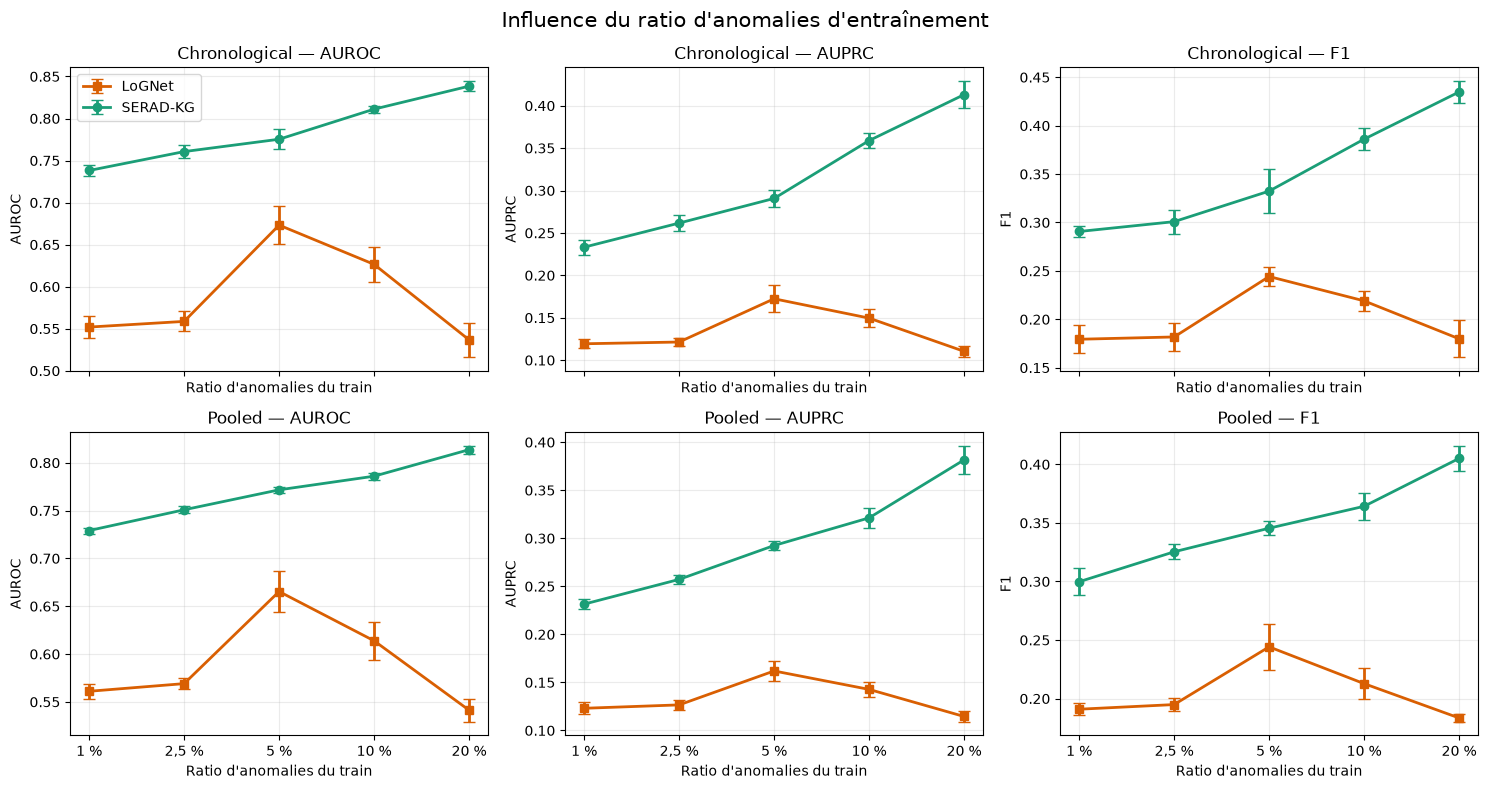

In [6]:
plot_metrics = {"auc_test": "AUROC", "auprc_test": "AUPRC", "f1_test": "F1"}
colors = {"lognet": "#d95f02", "serad_kg": "#1b9e77"}
markers = {"lognet": "s", "serad_kg": "o"}

figure, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for row_index, protocol in enumerate(PROTOCOLS):
    for column_index, (metric, metric_label) in enumerate(plot_metrics.items()):
        axis = axes[row_index, column_index]
        for model in MODELS:
            means = [aggregated.loc[(protocol, model, ratio), (metric, "mean")] for ratio in RATIOS]
            stds = [aggregated.loc[(protocol, model, ratio), (metric, "std")] for ratio in RATIOS]
            axis.errorbar(
                range(len(RATIOS)), means, yerr=stds,
                marker=markers[model], capsize=4, linewidth=2,
                color=colors[model], label=MODEL_LABELS[model],
            )
        axis.set_title(f"{'Chronological' if protocol == 'chronological_llm' else 'Pooled'} — {metric_label}")
        axis.set_xticks(range(len(RATIOS)), [RATIO_LABELS[ratio] for ratio in RATIOS])
        axis.set_xlabel("Ratio d'anomalies du train")
        axis.set_ylabel(metric_label)
        axis.grid(alpha=0.25)
        if row_index == 0 and column_index == 0:
            axis.legend()
figure.suptitle("Influence du ratio d'anomalies d'entraînement", fontsize=15)
figure.tight_layout()
plt.show()

## Sélection du ratio sur la validation

In [7]:
selection_rows = []
for protocol in PROTOCOLS:
    for model in MODELS:
        subset = results[(results["protocol"] == protocol) & (results["model"] == model)]
        validation_by_ratio = subset.groupby("ratio")["auprc_validation"].mean()
        selected_ratio = float(validation_by_ratio.idxmax())
        selected = subset[subset["ratio"] == selected_ratio]
        selection_rows.append(
            {
                "Protocole": "Chronological" if protocol == "chronological_llm" else "Pooled",
                "Méthode": MODEL_LABELS[model],
                "Ratio sélectionné": RATIO_LABELS[selected_ratio],
                "AUPRC validation": f"{french_number(selected.auprc_validation.mean())} ± {french_number(selected.auprc_validation.std(ddof=1))}",
                "AUROC test": f"{french_number(selected.auc_test.mean())} ± {french_number(selected.auc_test.std(ddof=1))}",
                "AUPRC test": f"{french_number(selected.auprc_test.mean())} ± {french_number(selected.auprc_test.std(ddof=1))}",
                "F1 test": f"{french_number(selected.f1_test.mean())} ± {french_number(selected.f1_test.std(ddof=1))}",
            }
        )

selection_table = pd.DataFrame(selection_rows)
display(selection_table.style.hide(axis="index").set_caption("Ratio choisi exclusivement sur l'AUPRC de validation"))

Protocole,Méthode,Ratio sélectionné,AUPRC validation,AUROC test,AUPRC test,F1 test
Chronological,LoGNet,5 %,"0,204 ± 0,027","0,673 ± 0,022","0,172 ± 0,016","0,244 ± 0,010"
Chronological,SERAD-KG,20 %,"0,402 ± 0,007","0,838 ± 0,006","0,413 ± 0,016","0,435 ± 0,011"
Pooled,LoGNet,5 %,"0,172 ± 0,016","0,665 ± 0,022","0,162 ± 0,011","0,244 ± 0,019"
Pooled,SERAD-KG,20 %,"0,408 ± 0,016","0,814 ± 0,004","0,382 ± 0,015","0,405 ± 0,011"


## Gains appariés de SERAD-KG sur LoGNet

In [8]:
gain_rows = []
for protocol in PROTOCOLS:
    for ratio in RATIOS:
        serad = results[(results.protocol == protocol) & (results.model == "serad_kg") & (results.ratio == ratio)].set_index("seed")
        lognet = results[(results.protocol == protocol) & (results.model == "lognet") & (results.ratio == ratio)].set_index("seed")
        row = {
            "Protocole": "Chronological" if protocol == "chronological_llm" else "Pooled",
            "Ratio": RATIO_LABELS[ratio],
        }
        for metric, label in (("auc_test", "Gain AUROC"), ("auprc_test", "Gain AUPRC"), ("f1_test", "Gain F1")):
            differences = serad[metric] - lognet[metric]
            interval = stats.t.interval(
                0.95, len(differences) - 1,
                loc=differences.mean(), scale=stats.sem(differences),
            )
            row[label] = (
                f"{french_number(differences.mean())} "
                f"[{french_number(interval[0])} ; {french_number(interval[1])}]"
            )
        gain_rows.append(row)

gain_table = pd.DataFrame(gain_rows)
display(gain_table.style.hide(axis="index").set_caption("Gain moyen [IC 95 %] de SERAD-KG"))

Protocole,Ratio,Gain AUROC,Gain AUPRC,Gain F1
Chronological,1 %,"0,186 [0,167 ; 0,205]","0,114 [0,105 ; 0,123]","0,111 [0,088 ; 0,135]"
Chronological,"2,5 %","0,202 [0,181 ; 0,223]","0,140 [0,132 ; 0,148]","0,119 [0,091 ; 0,147]"
Chronological,5 %,"0,102 [0,071 ; 0,133]","0,118 [0,104 ; 0,132]","0,088 [0,055 ; 0,122]"
Chronological,10 %,"0,185 [0,157 ; 0,212]","0,209 [0,193 ; 0,226]","0,167 [0,149 ; 0,184]"
Chronological,20 %,"0,302 [0,269 ; 0,334]","0,303 [0,277 ; 0,329]","0,255 [0,236 ; 0,273]"
Pooled,1 %,"0,168 [0,157 ; 0,179]","0,108 [0,098 ; 0,119]","0,109 [0,092 ; 0,125]"
Pooled,"2,5 %","0,182 [0,172 ; 0,191]","0,131 [0,119 ; 0,142]","0,130 [0,121 ; 0,139]"
Pooled,5 %,"0,106 [0,080 ; 0,133]","0,131 [0,119 ; 0,143]","0,101 [0,079 ; 0,124]"
Pooled,10 %,"0,172 [0,149 ; 0,195]","0,178 [0,163 ; 0,194]","0,151 [0,136 ; 0,167]"
Pooled,20 %,"0,272 [0,254 ; 0,291]","0,267 [0,244 ; 0,290]","0,222 [0,209 ; 0,234]"


## Conclusions

- **SERAD-KG surpasse LoGNet pour chaque ratio, dans les deux protocoles et sur les cinq seeds.**
- SERAD-KG progresse régulièrement quand le nombre d'anomalies d'entraînement augmente ; la validation sélectionne **20 %** pour pooled et chronological.
- LoGNet atteint son meilleur niveau à **5 %**, puis se dégrade à 10 % et 20 %.
- À 20 %, SERAD-KG atteint environ **0,382 d'AUPRC et 0,405 de F1** en pooled, et **0,413 d'AUPRC et 0,435 de F1** en chronological.
- La comparaison correspond à SERAD-KG complet contre LoGNet original. SERAD-KG utilise une BCE équilibrée et une sélection sur l'AUPRC, tandis que LoGNet utilise une BCE standard et une sélection sur la loss ; une variante LoGNet harmonisée permettrait d'isoler plus strictement l'effet de l'architecture.